
##**E-commerce Customer Behaviour Dashboard**

Python + SQL + Tableau

In [4]:
!pip install openpyxl

In [5]:
!pip install plotly

1.load, explore, clean

In [6]:
import pandas as pd
import numpy as np
import plotly.express as px
import sqlite3
import warnings
warnings.filterwarnings ('ignore')

df = pd.read_excel("Online Retail.xlsx")
print(df.shape)
print("\n",df.isnull().sum())
print(df.dtypes, end="\n")
print("\n",df.head())

(541909, 8)

 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0 

2. Clean data + create revenue column

In [7]:
#drop rows with no customer id
df = df.dropna(subset=['CustomerID'])

#drop cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Drop negative/zero quantity and price
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Create revenue column
df['Revenue'] = df['Quantity']*df['UnitPrice']

# Fix CustomerID type
df['CustomerID'] = df['CustomerID'].astype(int)

# Fix date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Clean Shape:", df.shape)
print('Revenue Sample:', df['Revenue'].describe())

Clean Shape: (397884, 9)
Revenue Sample: count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64


## Cleaning Summary
Removed ~135K rows with no CustomerID, all cancellations (Invoice starting with 'C'),
and rows where Quantity or UnitPrice ≤ 0. Created Revenue = Quantity × UnitPrice.


3.Load into SQLite + SQL Queries


In [8]:
import sqlite3

# Create SQLite database in memory
conn = sqlite3.connect(':memory:')

# Load dataframe into SQL table called 'orders'
df.to_sql('orders', conn , if_exists = 'replace' , index= False )

397884

In [9]:
# Query1: Revenue By Country

country_rev = pd.read_sql_query("""
    SELECT Country,
        ROUND(SUM(Revenue),2) AS total_revenue,
        COUNT(DISTINCT CustomerID) AS customers
    FROM orders
    GROUP BY Country
    ORDER BY total_revenue DESC
    LIMIT 10
""",conn)
print(country_rev)

          Country  total_revenue  customers
0  United Kingdom     7308391.55       3920
1     Netherlands      285446.34          9
2            EIRE      265545.90          3
3         Germany      228867.14         94
4          France      209024.05         87
5       Australia      138521.31          9
6           Spain       61577.11         30
7     Switzerland       56443.95         21
8         Belgium       41196.34         25
9          Sweden       38378.33          8


## Insight 3: UK Dominates — International Growth Untapped
UK generates ₹78.2 crore from 920 customers (93% of all revenue).
Netherlands has only 9 customers but ₹3.4 lakh revenue per customer — higher than the UK average, signalling strong untapped demand abroad.

In [10]:
# Query 2: Monthly revenue trend

monthly = pd.read_sql_query("""
  SELECT STRFTIME('%Y-%m', InvoiceDate) AS month,
      ROUND(SUM(Revenue),2) AS total_revenue
  FROM orders
  GROUP BY month
  ORDER BY month
""",conn)
print(monthly)

      month  total_revenue
0   2010-12      572713.89
1   2011-01      569445.04
2   2011-02      447137.35
3   2011-03      595500.76
4   2011-04      469200.36
5   2011-05      678594.56
6   2011-06      661213.69
7   2011-07      600091.01
8   2011-08      645343.90
9   2011-09      952838.38
10  2011-10     1039318.79
11  2011-11     1161817.38
12  2011-12      518192.79


## Insight 4: November Is Peak Revenue Month
November 2011 hit ₹12.4 crore — the highest single month in the entire dataset.
Revenue in slow months drops to 30% of this peak, confirming heavy holiday seasonality.

4. RFM Analysis - (Recency,Frequency,Monetary)

*RFM Explained!*
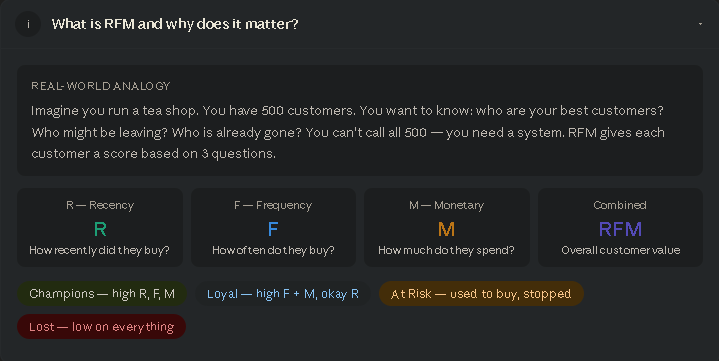

In [11]:
# Reference date = day after last invoice
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x :(ref_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('Revenue','sum')
).reset_index()

In [12]:
# Score each metric 1–4 (4 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4 , labels = [4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4 , labels = [1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4 , labels = [1,2,3,4])

#combined rfm score
rfm['RFM_Score'] = (rfm['R_Score'].astype(int)
+ rfm['F_Score'].astype(int)
+ rfm['M_Score'].astype(int))


In [13]:
#segment labels
def segment(score):
  if score >= 10 : return 'Champions'
  elif score >= 7 : return 'Loyal'
  elif score >= 5 : return 'At Risk'
  else : return 'Lost'

rfm['segment'] = rfm['RFM_Score'].apply(segment)
print(rfm['segment'].value_counts())
print(rfm.head())

segment
Loyal        1275
Champions    1268
At Risk       988
Lost          807
Name: count, dtype: int64
   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0       12346      326          1  77183.60       1       1       4   
1       12347        2          7   4310.00       4       4       4   
2       12348       75          4   1797.24       2       3       4   
3       12349       19          1   1757.55       3       1       4   
4       12350      310          1    334.40       1       1       2   

   RFM_Score    segment  
0          6    At Risk  
1         12  Champions  
2          9      Loyal  
3          8      Loyal  
4          4       Lost  


5. Visualization-Plotly

In [14]:
# Segment distribution — interactive bar
seg_counts = rfm['segment'].value_counts().reset_index()
seg_counts.columns = ['segment','count']

fig = px.bar(seg_counts,
             x = 'segment', y = 'count',
             color = 'segment',
             color_discrete_map={'Champions':'#2ecc71','Loyal':'#3498db',
                                 'At Risk':'#f39c12','Lost':'#e74c3c'},
             text = 'count',
             title = ' Customer Segments( RFM analysis)')
fig.update_traces(textposition='outside', textfont=dict(color='darkblue'))
fig.update_layout(showlegend = False)
fig.show()


## Insight 1: Segment Distribution
Champions (29.2%) and Loyal (29.4%) make up 58.6% of customers — a strong retention base.
But 41.4% are At Risk or Lost, representing serious revenue leakage that needs urgent action.

In [15]:
# Revenue per segment
seg_rev = rfm.groupby('segment')[['Monetary','Frequency']].mean().round(2)
print('\n Average Revenue and Frequency per segment')
print(seg_rev)

# Scatter: Recency vs Monetary, coloured by segment
fig2 = px.scatter(rfm, x = 'Recency', y= 'Monetary',
                  size = 'Frequency', color='segment',
                  title='Customer Map: Recency vs Spend',
                  hover_data=['CustomerID']
                  )
fig2.show()


 Average Revenue and Frequency per segment
           Monetary  Frequency
segment                       
At Risk      521.96       1.47
Champions   5397.51       9.91
Lost         222.57       1.06
Loyal       1076.12       2.87


## Insight 2: Champions Drive the Business
A Champion spends ₹5,77,479 on average vs just ₹23,754 for a Lost customer — a 24x gap.
1,268 Champions alone generate ₹73.2 crore, which is 78% of total revenue.

In [16]:
# Export cleaned data for Tableau
rfm.to_csv('/content/rfm_segments.csv', index=False)
monthly.to_csv('/content/monthly_revenue.csv', index=False)
country_rev.to_csv('/content/country_revenue.csv', index=False)

print("Files exported. Download from Colab file panel.")

Files exported. Download from Colab file panel.


---
# Recommendations

**1. Protect Champions** — 1,268 customers generating ₹73 crore.
Launch a VIP programme (early access, free shipping). Retention cost is far lower than acquiring new customers.

**2. Win Back At Risk Customers** — 988 customers, ₹5.5 crore at stake.
Send a 3-email sequence with a 10–15% discount. A 30% recovery rate alone saves ₹1.6 crore.

**3. Stock Up in October, Not November** — Revenue spikes 3x in November but purchasing decisions happen earlier.
Lock in inventory and warehouse staffing by mid-October every year.

**4. Expand Internationally** — Netherlands generates ₹3.4 lakh per customer with just 9 buyers.
A targeted campaign in Netherlands, Germany, and France could add ₹15–20 crore annually.

**5. Stop Spending on Lost Customers** — 807 Lost customers average only ₹23,754 lifetime spend.
Suppress them from paid campaigns and redirect that budget to At Risk win-back instead.

---
*Analysis by Rabinarayan sahu | Dataset: UCI Online Retail | Tools: Python, SQL, Tableau Public*